## <span style = 'color:orange; font-family:Wild Wolf'>Polynomial regression</span>
> 1 input | 1 output

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [15]:
df = pd.read_csv('coffee.csv')
df.head()

,Temperature,Coffee_Sales
0,14.981605,150.800298
1,38.028572,122.531718
2,29.279758,120.509181
3,23.946339,117.580908
4,6.240746,178.483961


In [20]:
x = df['Temperature'].values
y = df['Coffee_Sales'].values

x = df.iloc[:, 0:1]
y = df.iloc[:, -1]

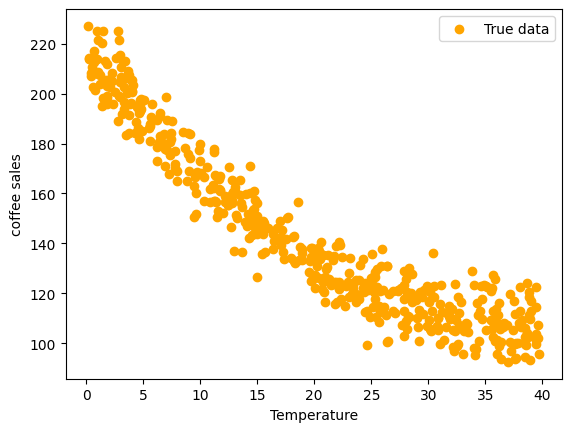

In [21]:
plt.scatter(x,y,color = 'orange', label = 'True data')
plt.xlabel('Temperature')
plt.ylabel('coffee sales')
plt.legend()
plt.show()

In [22]:
# sklearn for comparison
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_sk = lr.predict(x_test)

print('Intercept: ',lr.intercept_)
print('Coef: ',lr.coef_)
print('r2_Score: ',r2_score(y_test, y_pred_sk))

Intercept:  198.47144834154173
Coef:  [-2.75356738]
r2_Score:  0.8805364916582121


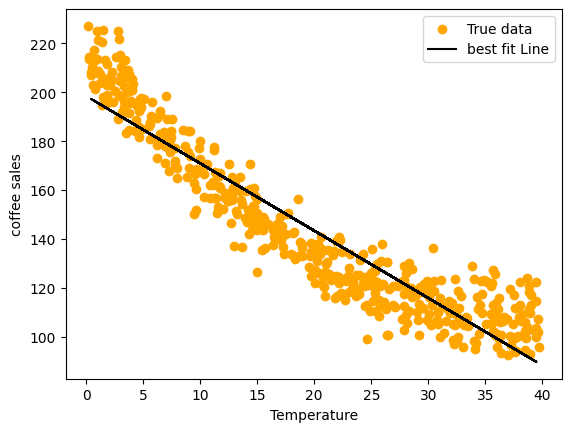

In [23]:
plt.scatter(x,y,color = 'orange', label = 'True data')
plt.plot(x_test, y_pred_sk, color = 'k', label = 'best fit Line')
plt.xlabel('Temperature')
plt.ylabel('coffee sales')
plt.legend()
plt.show()

### Polynomial Features

In [45]:
poly = PolynomialFeatures(degree = 2, include_bias = True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

lr2 = LinearRegression()
lr2.fit(x_train_trans, y_train)
y_pred = lr2.predict(x_test_trans)

print('Intercept: ',lr2.intercept_)
print('Coef: ',lr2.coef_)
print('r2_Score: ',r2_score(y_test, y_pred))

Intercept:  216.87585558800387
Coef:  [ 0.         -5.6602181   0.07310351]
r2_Score:  0.9546294400341421


In [46]:
# polynomial curve
x_new = np.linspace(x.min(), x.max(), 500).reshape(-1,1)
x_new_poly = poly.transform(x_new)
y_new = lr2.predict(x_new_poly)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


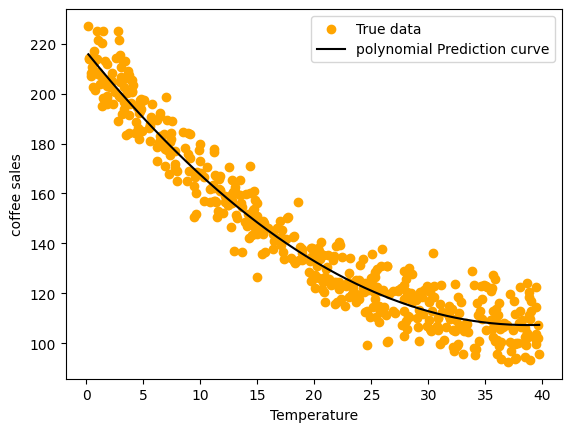

In [47]:
plt.scatter(x,y,color = 'orange', label = 'True data')
# plt.plot(x_test, y_pred_sk, color = 'k', label = 'best fit Line')
plt.plot(x_new, y_new, color = 'k', label = 'polynomial Prediction curve')
plt.xlabel('Temperature')
plt.ylabel('coffee sales')
plt.legend()
plt.show()